#张量

In [2]:
import torch
import numpy as np

**shape**是张量维度的元组。在下方的函数中，它决定了输出张量的维度。

In [3]:
shape = (2, 3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")

Random Tensor: 
 tensor([[0.0851, 0.7133, 0.7096],
        [0.3569, 0.9096, 0.0129]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


`torch.ones_like(input) `
创建一个全 1 张量；新张量 x_ones 完全复制 x_data 的三大属性：形状、数据类型、存储设备（CPU/GPU）；

对比区分：和 `torch.ones(shape) `不同，ones_like 不用手动写维度，直接复用参考张量的尺寸；

In [13]:
x_ones = torch.ones_like(rand_tensor) # retains the properties of x_data
print(f"Ones Tensor: \n {x_ones} \n")

x_rand = torch.rand_like(ones_tensor, dtype=torch.float) # overrides the datatype of x_data
print(f"Random Tensor: \n {x_rand} \n")

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Random Tensor: 
 tensor([[0.5627, 0.0993, 0.3679],
        [0.0520, 0.1104, 0.3268]]) 



张量属性

In [14]:
tensor = torch.rand(3, 4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


`tensor[:,1] = 0`
切片赋值：

: 代表选取全部行；

1 代表选取第 2 列（索引从 0 开始）；
把张量所有行的第 2 列全部覆盖赋值为 0。

In [15]:
tensor = torch.ones(4, 4)
tensor[:,1] = 0
print(tensor)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])



`torch.cat([tensor, tensor, tensor], dim=1)`
1. **作用**：沿指定维度拼接多个张量，不新增维度；
2. 参数说明：
   - `[tensor, tensor, tensor]`：待拼接的3个相同张量组成列表；
   - `dim=1`：沿**第2维（列维度）**拼接；

#### 关键区分
- `dim=0`：上下堆叠（行拼接）；
- `dim=1`：左右横向拼接（列拼接）；
和 `torch.stack` 不同，`cat` 不会增加新维度。

In [20]:
t1 = torch.cat([tensor, tensor, tensor], dim=0)
print(t1)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


In [18]:
t1 = torch.stack([tensor, tensor, tensor], dim=2)
print(t1)

tensor([[[1., 1., 1.],
         [0., 0., 0.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [0., 0., 0.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [0., 0., 0.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [0., 0., 0.],
         [1., 1., 1.],
         [1., 1., 1.]]])


###张量乘法

运算符：`* / tensor.mul()`

规则：两个张量同形状，对应位置数字相乘，输出形状不变。
示例：[[1,0],[1,1]] * [[1,0],[1,1]] = [[1,0],[1,1]]

###矩阵乘法（线性代数矩阵积）

运算符：`@ / tensor.matmul()`

规则：满足矩阵相乘维度规则，第一个张量列数 = 第二个张量行数；文中搭配tensor.T（转置）使用，输出新矩阵。

In [ ]:
# This computes the element-wise product
print(f"tensor.mul(tensor) \n {tensor.mul(tensor)} \n")
# Alternative syntax:
print(f"tensor * tensor \n {tensor * tensor}")

In [ ]:
print(f"tensor.matmul(tensor.T) \n {tensor.matmul(tensor.T)} \n")
# Alternative syntax:
print(f"tensor @ tensor.T \n {tensor @ tensor.T}")

####原地操作
**带有_后缀的操作**均为原地操作。例如：x.copy_(y)、x.t_() 会修改x本身。

In [ ]:
print(tensor, "\n")
tensor.add_(5)
print(tensor)

# torch.autograd

**torch.autograd** 是 PyTorch 的自动微分引擎，为神经网络训练提供支持。

###神经网络（NNs）

是在某些输入数据上执行的嵌套函数集合。这些函数由参数（由权重和偏置组成）定义，在PyTorch中这些参数存储在张量中。

### 训练神经网络分为两个步骤：

**前向传播：**
在前向传播过程中，神经网络会对正确输出做出最准确的预测。它会将输入数据通过自身的每一个函数层来完成这一预测。


**反向传播：**
在反向传播过程中，神经网络会根据其预测结果的误差按比例调整参数。具体做法是从输出层反向遍历，收集误差相对于函数参数的导数（梯度），再通过梯度下降法优化参数。

In [21]:
import torch
from torchvision.models import resnet18, ResNet18_Weights
model = resnet18(weights=ResNet18_Weights.DEFAULT)
data = torch.rand(1, 3, 64, 64)
labels = torch.rand(1, 1000)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 316MB/s]


我们将输入数据通过模型的每一层运行，以做出预测。这就是前向传播。

In [22]:
prediction = model(data) # forward pass

我们使用模型的预测结果和对应的标签来计算误差（loss）。下一步是将该误差通过网络反向传播。

在误差张量上调用 **.backward() **时，反向传播就会启动。随后，Autograd 会计算每个模型参数的梯度，并将其存储在参数的 .grad 属性中。

In [24]:
loss = (prediction - labels).sum()
loss.backward() # backward pass

接下来，我们加载一个优化器，本例中是学习率为 0.01、动量为 0.9 的随机梯度下降（SGD）优化器。我们将模型的所有参数都注册到该优化器中。

`model.parameters () `返回生成器迭代器，遍历模型所有可训练参数张量（权重 weight、偏置 bias）。传入优化器optimizer，让优化器更新权重；


In [25]:
optim = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

最后，我们调用`.step()`来启动梯度下降。优化器根据存储在`.grad`中的梯度来调整每个参数。

In [26]:
optim.step() #gradient descent

在神经网络（NN）中，不计算梯度的参数通常被称为**冻结参数**。

在微调过程中，我们会冻结模型的大部分参数，通常只修改分类器层以对新标签进行预测。我们来看一个简单的示例来演示这一点。和之前一样，我们加载一个预训练的 resnet18 模型，并冻结其所有参数。

In [27]:
from torch import nn, optim

model = resnet18(weights=ResNet18_Weights.DEFAULT)

# Freeze all the parameters in the network
for param in model.parameters():
    param.requires_grad = False

假设我们要在一个包含 10 个标签的新数据集上对模型进行微调。在 ResNet 中，分类器是最后的线性层 model.fc。我们可以直接将其替换为一个新的线性层（默认未冻结），用它来作为我们的分类器。

**前提**：这里的model一般是 ResNet18 这类标准 ResNet 网络
ResNet 主干提取图像特征后，输出512 维特征向量；
原始`model.fc`是模型末尾全连接层，默认输出 1000 类（ImageNet 分类）。


**代码作用**：替换模型最后的分类头
`nn.Linear(512, 10)`：输入 512 维特征，映射到 10 维输出；
把原 1000 分类改成10 分类任务。

**核心逻辑：** 冻结 / 微调主干卷积层，只替换最后一层适配自定义分类数量，是迁移学习标准写法。

In [28]:
model.fc = nn.Linear(512, 10)

###nn与torchvision区分
**torch.nn（nn）**
PyTorch 核心底层工具：卷积、全连接、激活、损失、网络基类，所有神经网络的积木。
不管你用不用 torchvision，搭网络、训练都离不开它。

**torchvision**
上层工具包，专门给图像任务服务：
内置现成预训练模型 resnet/vgg/vit…
图像数据集、图像数据增强
它只是封装好的成品模型库，内部底层依然全是 nn 的层实现的。

In [29]:
# Optimize only the classifier
optimizer = optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

现在模型中除了model.fc的参数外，所有参数都被冻结。唯一计算梯度的参数是model.fc的权重和偏置。



#Neural Networks

神经网络可以使用 `torch.nn` 包来构建。

nn 依赖 autograd 来定义模型并进行求导。nn.Module 包含多个层，以及一个返回 output 的方法 forward(input)。

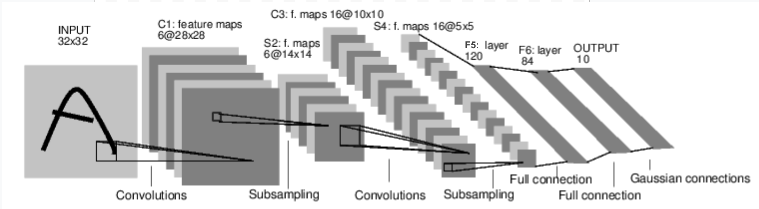

这是一个简单的前馈神经网络。它接收输入，将其依次通过多个层进行处理，最终输出结果。

###神经网络的典型训练流程

*   Define the neural network that has some learnable parameters (or weights)
定义一个带有若干可学习参数（或权重）的神经网络

*   Iterate over a dataset of inputs 遍历输入数据集
*   Process input through the network 通过网络处理输入
*   Compute the loss (how far is the output from being correct)
计算损失（输出与正确结果的差距）

*   Propagate gradients back into the network’s parameters
将梯度反向传播到网络的参数中

*   Update the weights of the network, typically using a simple update rule: weight = weight - learning_rate * gradient
更新网络的权重，通常使用简单的更新规则：`weight = weight - learning_rate * gradient`



###定义网络

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):

    def __init__(self):
        super().__init__()
        # 卷积层：1个输入图像通道，6个输出通道，5×5卷积核
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        # 全连接层（仿射变换：y = Wx + b）
        self.fc1 = nn.Linear(16 * 5 * 5, 120)  # 5*5是卷积池化后的特征图尺寸
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, input):
        # 卷积层C1：输入单通道图像，输出6通道特征图，卷积核5×5，使用ReLU激活
        # 输出张量形状 (N, 6, 28, 28)，N代表批量大小
        c1 = F.relu(self.conv1(input))
        # 下采样层S2：2×2最大池化，无可学习参数，输出形状 (N, 6, 14, 14)
        s2 = F.max_pool2d(c1, (2, 2))
        # 卷积层C3：6通道输入，16通道输出，5×5卷积核，ReLU激活
        # 输出张量形状 (N, 16, 10, 10)
        c3 = F.relu(self.conv2(s2))
        # 下采样层S4：2×2最大池化，无参数，2是(2, 2)的简写两种写法完全等价，输出形状 (N, 16, 5, 5)
        s4 = F.max_pool2d(c3, 2)
        # 展平操作：只保留batch维度，把后面所有维度拉成一维，输出 (N, 400)
        s4 = torch.flatten(s4, 1)
        # 全连接层F5：输入400维特征，输出120维，ReLU激活
        f5 = F.relu(self.fc1(s4))
        # 全连接层F6：输入120维，输出84维，ReLU激活
        f6 = F.relu(self.fc2(f5))
        # 输出层：输入84维特征，最终输出10个分类得分
        output = self.fc3(f6)
        return output


net = Net()
print(net)

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


###class Net(nn.Module)
1. **继承关系**
`Net` 自定义网络类继承 `nn.Module`，这是PyTorch所有网络层/模型的基类，自动支持参数管理、梯度、GPU迁移、保存加载等功能。

2. **__init__ 构造函数**
- `super().__init__()`：必须调用，初始化父类模块；
- 定义**可学习层**：`Conv2d`卷积层、`Linear`全连接层，这些层内部自带权重、偏置，会自动注册为模型参数。

3. **forward 前向传播函数（核心）**
- 必须手动实现，定义数据从输入到输出的计算流程；
- 使用 `F.relu`、`F.max_pool2d`、`torch.flatten` 等无参数函数做激活、池化、展平；
- 输入张量逐层运算，最后返回分类输出；
- 无需手写反向传播，autograd 根据 forward 计算图自动生成反向梯度逻辑。

实例化： `net = Net()`

###F（torch.nn.functional）和 nn 的核心区别
*   torch.nn（你导入的 nn）：类形式层，带可训练参数，写在 __init__ 里
例：nn.Conv2d、nn.Linear、nn.BatchNorm2d，内部存 weight/bias，会被优化器更新
*   torch.nn.functional（F）：纯函数，无参数，只做运算，写在 forward 里
例：ReLU、max_pool2d、softmax、cross_entropy、dropout、卷积运算等


你只需要定义forward函数， **而backward函数（用于计算梯度）会通过autograd自动为你生成。** 你可以在forward函数中使用任意张量操作。

模型的可学习参数由 net.parameters() 返回

In [31]:
params = list(net.parameters())
print(len(params))
print(params[0].size())  # conv1's .weight

10
torch.Size([6, 1, 5, 5])


**该网络（LeNet）的期望输入尺寸为32×32**

代码里没有任何一行写死、强制限制输入必须是 32×32，只是网络结构参数是按输入 32×32 算出来的，一旦尺寸不对，维度就会对不上报错。

网络定义全程没有写 32，卷积层本身不限制输入尺寸，随便多大图都能进卷积。

限制来自最后全连接层 16 * 5 * 5 这个固定数字：这个 5 是「输入 32×32」经过两层卷积 + 两层池化后算出来的特征图边长。 全连接层输入维度写死 400，这个 400 是专为 32×32 输入设计的，间接强制输入必须 32；

**torch.randn(1, 1, 32, 32)**
四维参数含义
张量格式：[batch_size, channel, H, W]

最终out形状(1,10)

In [32]:
input = torch.randn(1, 1, 32, 32)
out = net(input)
print(out)

tensor([[-0.0654,  0.0761,  0.1091, -0.0085, -0.0585,  0.0505, -0.0994,  0.0197,
         -0.0670, -0.0973]], grad_fn=<AddmmBackward0>)


将所有参数的梯度缓冲区置零，并使用随机梯度进行反向传播：

`net.zero_grad()`

模型所有可学习参数（卷积权重、偏置、全连接层参数）的梯度缓冲区清零。
PyTorch 梯度会累加，不置零会叠加上一轮梯度，导致更新出错。

`out.backward(torch.randn(1, 10))`

正常反向传播默认对标量 loss 求导；若输出是多维张量（本例 out 形状 [1,10]，10 分类得分），backward 需要传入同形状张量作为梯度权重。
这里传入随机正态张量，等价于对输出各维度施加随机梯度信号，触发整条网络的自动微分，计算所有参数梯度并存入 .grad。

In [33]:
net.zero_grad()
out.backward(torch.randn(1, 10))

![image.png](![image.png](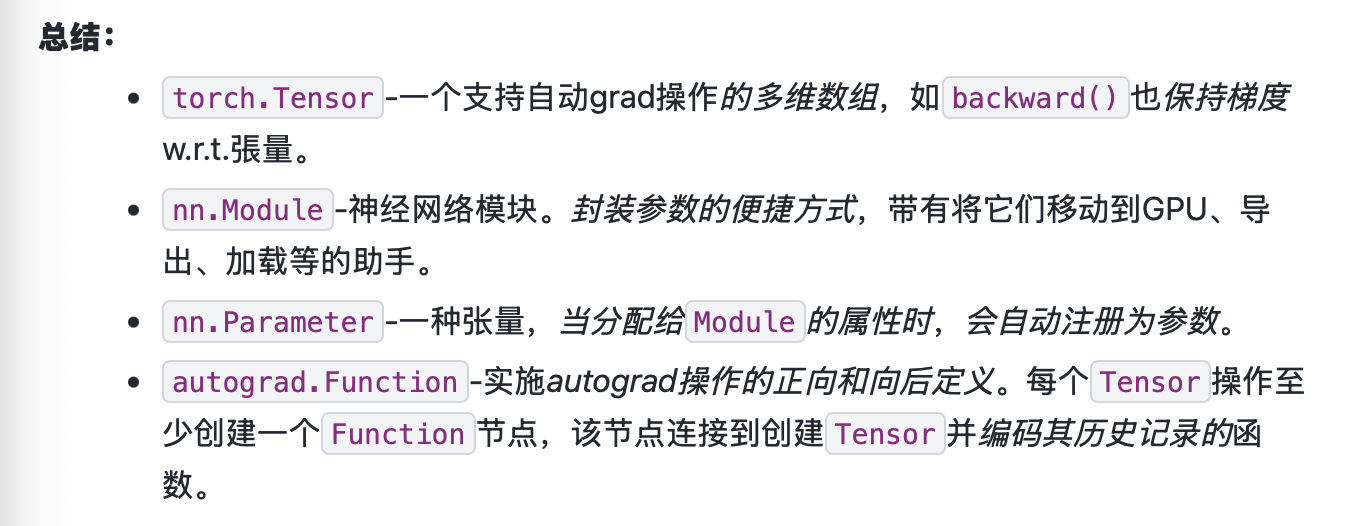...)